# Fragmentation And Recombination Visualization

This notebook focuses on the graph-level chemistry in `src/fragrec.py`:

1. What the original molecules look like
2. What happens when one bond is broken
3. How many one-step fragments are generated
4. What recombined products look like
5. How many unique recombinants are produced from a fragment pool


In [8]:
import math
import os
import sys
from itertools import product

ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from data.seed_species import SEEDS, TARGET
from src.fragrec import one_step_fragment, one_step_recombine_pair, recombine_pool
from src.molecule import MoleculeGraph, dedupe, has_valid_valence

ATOM_COLORS = {
    'H': '#d9d9d9',
    'C': '#4d4d4d',
    'O': '#d62728',
    'N': '#1f77b4',
    'Li': '#9467bd',
    'F': '#2ca02c',
}
BASE_EDGE_COLOR = '#777777'
BROKEN_BOND_COLOR = '#ff7f0e'
FORMED_BOND_COLOR = '#2ca02c'
MAX_FRAGMENT_PANELS = 6
MAX_RECOMBINATION_PANELS = 6
RUN_FULL_POOL_RECOMBINATION = False


def heavy_atom_count(mol):
    return sum(1 for _, d in mol.graph.nodes(data=True) if d['element'] != 'H')


def sort_mols(mols):
    return sorted(
        mols,
        key=lambda m: (heavy_atom_count(m), m.formula, m.charge, m.spin, m.n_atoms, m.n_bonds),
    )


def component_layout(graph):
    positions = {}
    x_offset = 0.0
    components = [sorted(c) for c in nx.connected_components(graph)]
    for comp_nodes in components:
        sub = graph.subgraph(comp_nodes).copy()
        if sub.number_of_nodes() == 1:
            node = next(iter(sub.nodes()))
            local_pos = {node: np.array([0.0, 0.0])}
            width = 1.0
        else:
            local_pos = nx.kamada_kawai_layout(sub)
            xs = [p[0] for p in local_pos.values()]
            width = (max(xs) - min(xs)) + 1.5
        for node, pos in local_pos.items():
            positions[node] = np.array([pos[0] + x_offset, pos[1]])
        x_offset += width
    return positions


def normalize_edge(edge):
    u, v = edge
    return tuple(sorted((u, v)))


def draw_molecule(ax, mol, title='', show_edge_ids=False, highlight_edges=None, highlight_color=BROKEN_BOND_COLOR):
    graph = mol.graph
    pos = component_layout(graph)
    node_colors = [ATOM_COLORS.get(d['element'], '#bbbbbb') for _, d in graph.nodes(data=True)]
    node_labels = {n: f"{n}:{d['element']}" for n, d in graph.nodes(data=True)}
    edge_list = list(graph.edges())
    highlight_edges = {normalize_edge(edge) for edge in (highlight_edges or [])}
    highlighted = [edge for edge in edge_list if normalize_edge(edge) in highlight_edges]

    nx.draw_networkx_nodes(graph, pos, ax=ax, node_color=node_colors, node_size=850, edgecolors='black')
    nx.draw_networkx_edges(graph, pos, ax=ax, edgelist=edge_list, width=2.0, edge_color=BASE_EDGE_COLOR)
    if highlighted:
        nx.draw_networkx_edges(graph, pos, ax=ax, edgelist=highlighted, width=4.5, edge_color=highlight_color)
    nx.draw_networkx_labels(graph, pos, labels=node_labels, ax=ax, font_size=9, font_color='white')

    if show_edge_ids and edge_list:
        edge_labels = {edge: str(i) for i, edge in enumerate(edge_list)}
        nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, ax=ax, font_size=9)

    summary = f"formula={mol.formula}, q={mol.charge}, spin={mol.spin}"
    ax.set_title(f"{title}\n{summary}" if title else summary, fontsize=11)
    ax.axis('off')


def show_gallery(mols, titles=None, cols=4, show_edge_ids=False, figsize_per_panel=3.8, highlight_edges_list=None, highlight_color=BROKEN_BOND_COLOR):
    mols = list(mols)
    if not mols:
        print('Nothing to draw.')
        return

    titles = titles or [''] * len(mols)
    highlight_edges_list = highlight_edges_list or [None] * len(mols)
    cols = max(1, min(cols, len(mols)))
    rows = math.ceil(len(mols) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per_panel, rows * figsize_per_panel))

    if isinstance(axes, np.ndarray):
        axes = axes.ravel().tolist()
    else:
        axes = [axes]

    for ax, mol, title, highlight_edges in zip(axes, mols, titles, highlight_edges_list):
        draw_molecule(ax, mol, title=title, show_edge_ids=show_edge_ids, highlight_edges=highlight_edges, highlight_color=highlight_color)

    for ax in axes[len(mols):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


def break_each_bond_with_context(mol):
    results = []
    edge_list = list(mol.graph.edges())
    for bond_idx, (u, v) in enumerate(edge_list):
        graph = mol.graph.copy()
        graph.remove_edge(u, v)
        products = []
        for comp_nodes in nx.connected_components(graph):
            comp = graph.subgraph(comp_nodes).copy()
            mapping = {old: new for new, old in enumerate(comp.nodes())}
            comp = nx.relabel_nodes(comp, mapping)
            products.append(
                MoleculeGraph(
                    comp,
                    charge=0,
                    spin=(mol.spin + 1) % 2,
                    name=f"frag({mol.name})",
                )
            )
        results.append({
            'bond_idx': bond_idx,
            'bond': (u, v),
            'elements': (mol.graph.nodes[u]['element'], mol.graph.nodes[v]['element']),
            'products': products,
        })
    return results


def recombine_pair_with_context(a, b):
    results = []
    seen = set()
    n_a = a.graph.number_of_nodes()
    for i, j in product(a.graph.nodes(), b.graph.nodes()):
        graph = nx.disjoint_union(a.graph, b.graph)
        new_bond = (i, j + n_a)
        graph.add_edge(*new_bond)
        recomb = MoleculeGraph(
            graph,
            charge=a.charge + b.charge,
            spin=(a.spin + b.spin) % 2,
            name=f"recomb({a.name},{b.name})",
        )
        if not has_valid_valence(recomb) or not nx.is_connected(graph):
            continue
        signature = recomb.canonical_hash()
        if signature in seen:
            continue
        seen.add(signature)
        results.append({
            'product': recomb,
            'new_bond': new_bond,
        })
    return sorted(
        results,
        key=lambda item: (
            heavy_atom_count(item['product']),
            item['product'].formula,
            item['product'].charge,
            item['product'].spin,
            item['product'].n_atoms,
            item['product'].n_bonds,
        ),
    )

## 1. Original molecules

The seed set is the starting point of the reaction network.


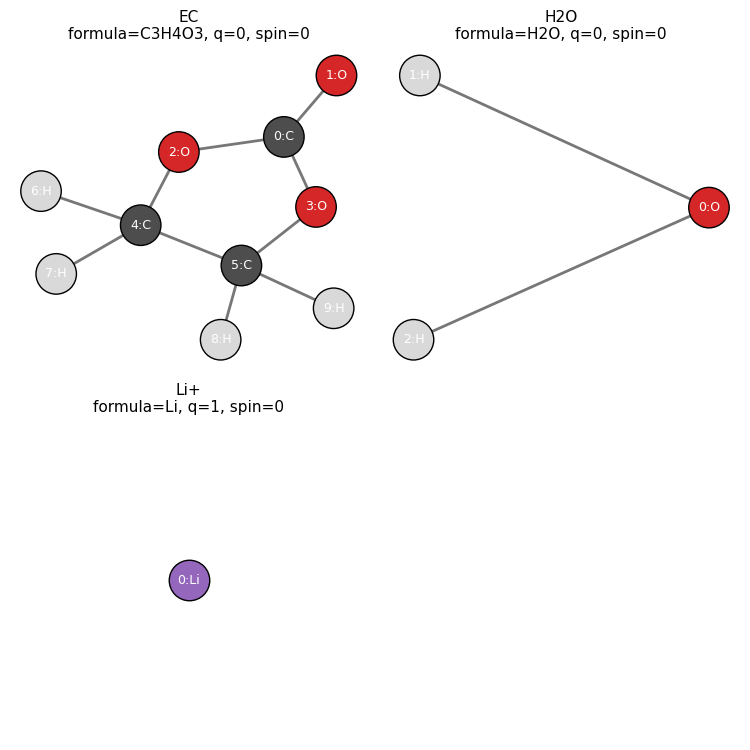

EC    formula=C3H4O3      atoms=10  bonds=10  charge=+0  spin=0
H2O   formula=H2O         atoms= 3  bonds= 2  charge=+0  spin=0
Li+   formula=Li          atoms= 1  bonds= 0  charge=+1  spin=0


In [2]:
seed_mols = [SEEDS['EC'], SEEDS['H2O'], SEEDS['Li+']]
titles = [m.name or m.formula for m in seed_mols]
show_gallery(seed_mols, titles=titles, cols=2, show_edge_ids=False)

for mol in seed_mols:
    print(f"{mol.name:4s}  formula={mol.formula:10s}  atoms={mol.n_atoms:2d}  bonds={mol.n_bonds:2d}  charge={mol.charge:+d}  spin={mol.spin}")


## 2. Pick one molecule and inspect its bonds

Change `focus_key` if you want to inspect a different seed. For fragmentation, `EC` is the most interesting one.


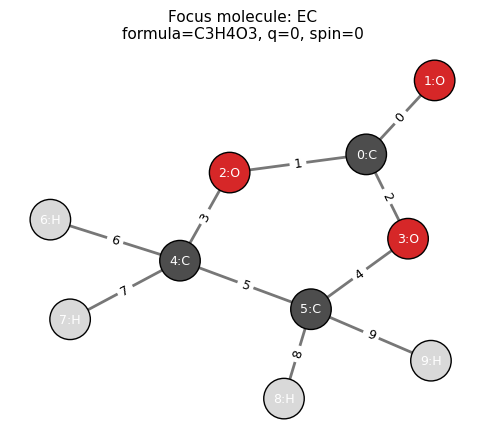

Inspecting EC: formula=C3H4O3, atoms=10, bonds=10, charge=+0, spin=0
bond  0: nodes (0, 1) = C-O
bond  1: nodes (0, 2) = C-O
bond  2: nodes (0, 3) = C-O
bond  3: nodes (2, 4) = O-C
bond  4: nodes (3, 5) = O-C
bond  5: nodes (4, 5) = C-C
bond  6: nodes (4, 6) = C-H
bond  7: nodes (4, 7) = C-H
bond  8: nodes (5, 8) = C-H
bond  9: nodes (5, 9) = C-H


In [3]:
focus_key = 'EC'
focus = SEEDS[focus_key]

fig, ax = plt.subplots(figsize=(6, 5))
draw_molecule(ax, focus, title=f"Focus molecule: {focus.name}", show_edge_ids=True)
plt.show()

print(f"Inspecting {focus.name}: formula={focus.formula}, atoms={focus.n_atoms}, bonds={focus.n_bonds}, charge={focus.charge:+d}, spin={focus.spin}")
for bond_idx, (u, v) in enumerate(focus.graph.edges()):
    eu = focus.graph.nodes[u]['element']
    ev = focus.graph.nodes[v]['element']
    print(f"bond {bond_idx:2d}: nodes ({u}, {v}) = {eu}-{ev}")


## 3. Break one bond

`break_each_bond_with_context` keeps track of which bond was removed and what connected components remain. This is slightly more verbose than `one_step_fragment`, but it is useful for visualization.


In [4]:
cuts = break_each_bond_with_context(focus)
total_fragment_objects = sum(len(item['products']) for item in cuts)
unique_fragments = sort_mols(one_step_fragment(focus))

print(f"Breaking each of the {focus.n_bonds} bonds once produces {total_fragment_objects} fragment objects in total.")
print(f"After deduplication, the project keeps {len(unique_fragments)} unique one-step fragment species.")
print()
for item in cuts:
    formulas = [p.formula for p in item['products']]
    u, v = item['bond']
    eu, ev = item['elements']
    print(f"bond {item['bond_idx']:2d} ({u}-{v}, {eu}-{ev}) -> {len(item['products'])} fragment(s): {formulas}")


Breaking each of the 10 bonds once produces 15 fragment objects in total.
After deduplication, the project keeps 7 unique one-step fragment species.

bond  0 (0-1, C-O) -> 2 fragment(s): ['C3H4O2', 'O']
bond  1 (0-2, C-O) -> 1 fragment(s): ['C3H4O3']
bond  2 (0-3, C-O) -> 1 fragment(s): ['C3H4O3']
bond  3 (2-4, O-C) -> 1 fragment(s): ['C3H4O3']
bond  4 (3-5, O-C) -> 1 fragment(s): ['C3H4O3']
bond  5 (4-5, C-C) -> 1 fragment(s): ['C3H4O3']
bond  6 (4-6, C-H) -> 2 fragment(s): ['C3H3O3', 'H']
bond  7 (4-7, C-H) -> 2 fragment(s): ['C3H3O3', 'H']
bond  8 (5-8, C-H) -> 2 fragment(s): ['C3H3O3', 'H']
bond  9 (5-9, C-H) -> 2 fragment(s): ['C3H3O3', 'H']


Showing bond 0: nodes (0, 1) = C-O


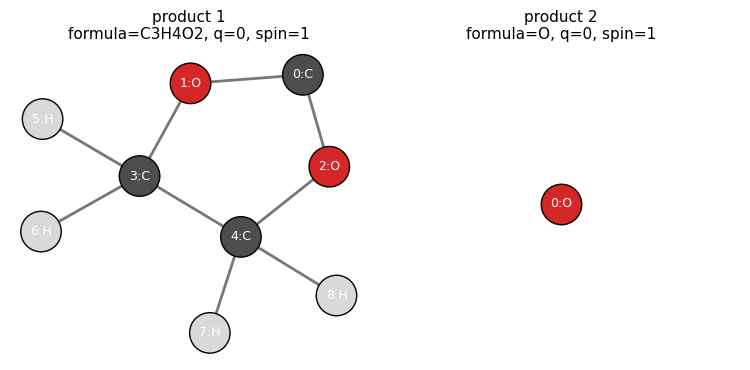

In [5]:
bond_to_show = 0  # edit this index to inspect a different bond
item = cuts[bond_to_show]
u, v = item['bond']
eu, ev = item['elements']
print(f"Showing bond {bond_to_show}: nodes ({u}, {v}) = {eu}-{ev}")
titles = [f"product {i + 1}" for i in range(len(item['products']))]
show_gallery(item['products'], titles=titles, cols=max(1, len(item['products'])))


## 4. Unique one-step fragments

`one_step_fragment` removes graph-isomorphic duplicates. These are the species that flow into the later network-building stages.


Unique one-step fragments for EC: 7
fragment  0: formula=H        atoms= 1 bonds= 0 charge=+0 spin=1
fragment  1: formula=O        atoms= 1 bonds= 0 charge=+0 spin=1
fragment  2: formula=C3H4O2   atoms= 9 bonds= 9 charge=+0 spin=1
fragment  3: formula=C3H3O3   atoms= 9 bonds= 9 charge=+0 spin=1
fragment  4: formula=C3H4O3   atoms=10 bonds= 9 charge=+0 spin=1
fragment  5: formula=C3H4O3   atoms=10 bonds= 9 charge=+0 spin=1
fragment  6: formula=C3H4O3   atoms=10 bonds= 9 charge=+0 spin=1


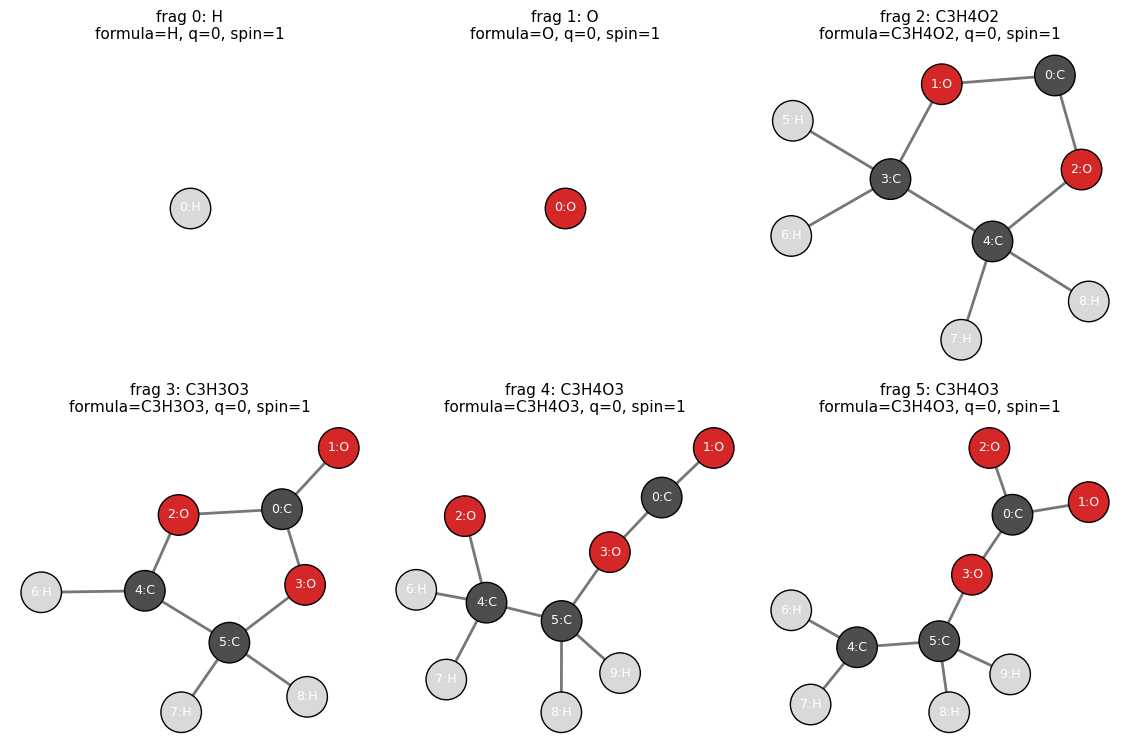

Showing 6 of 7 unique fragments.


In [6]:
print(f"Unique one-step fragments for {focus.name}: {len(unique_fragments)}")
for i, mol in enumerate(unique_fragments):
    print(f"fragment {i:2d}: formula={mol.formula:8s} atoms={mol.n_atoms:2d} bonds={mol.n_bonds:2d} charge={mol.charge:+d} spin={mol.spin}")

fragment_demo = unique_fragments[:MAX_FRAGMENT_PANELS]
titles = [f"frag {i}: {mol.formula}" for i, mol in enumerate(fragment_demo)]
show_gallery(fragment_demo, titles=titles, cols=3)
print(f"Showing {len(fragment_demo)} of {len(unique_fragments)} unique fragments.")


## 5. Recombine two fragments

Pick two fragment indices from the list above. `one_step_recombine_pair` tries one new bond between every atom pair across the two fragments and keeps only connected, valence-feasible products.


Recombining fragment 0 (H) with fragment 1 (O)
Unique recombinants from this pair: 1


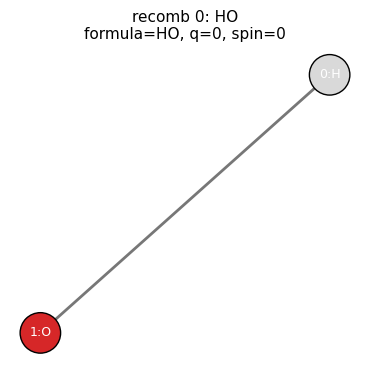

Showing 1 of 1 recombinants from this pair.


In [9]:
frag_a_idx = 0
frag_b_idx = 1
frag_a = unique_fragments[frag_a_idx]
frag_b = unique_fragments[frag_b_idx]

print(f"Recombining fragment {frag_a_idx} ({frag_a.formula}) with fragment {frag_b_idx} ({frag_b.formula})")
pair_recombinants = sort_mols(one_step_recombine_pair(frag_a, frag_b))
print(f"Unique recombinants from this pair: {len(pair_recombinants)}")

recomb_demo = pair_recombinants[:MAX_RECOMBINATION_PANELS]
titles = [f"recomb {i}: {mol.formula}" for i, mol in enumerate(recomb_demo)]
show_gallery(recomb_demo, titles=titles, cols=3)
print(f"Showing {len(recomb_demo)} of {len(pair_recombinants)} recombinants from this pair.")


## 6. Recombine the full fragment pool

This mirrors what the library does at pool level: all fragment pairs plus self-pairs, then graph-isomorphism deduplication.


In [ ]:
if RUN_FULL_POOL_RECOMBINATION:
    recombined_pool = sort_mols(recombine_pool(unique_fragments))
    print(f"Unique fragment species entering recombination: {len(unique_fragments)}")
    print(f"Unique recombinants from the full fragment pool: {len(recombined_pool)}")

    for i, mol in enumerate(recombined_pool[:MAX_RECOMBINATION_PANELS]):
        print(f"recomb {i:2d}: formula={mol.formula:10s} atoms={mol.n_atoms:2d} bonds={mol.n_bonds:2d} charge={mol.charge:+d} spin={mol.spin}")

    titles = [f"recomb {i}: {mol.formula}" for i, mol in enumerate(recombined_pool[:MAX_RECOMBINATION_PANELS])]
    show_gallery(recombined_pool[:MAX_RECOMBINATION_PANELS], titles=titles, cols=3)
else:
    print('Skipping full fragment-pool recombination for a faster teaching demo.')
    print('Set RUN_FULL_POOL_RECOMBINATION = True in the first code cell if you want the full enumeration.')
